In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [2]:
# Task 1

df['sex'] = pd.get_dummies(df['sex'], drop_first=True, dtype=int)
df['smoker'] = pd.get_dummies(df['smoker'], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

In [3]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


In [4]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

We have 8 features after encoding. We encode before doing feature selection because the model understands numbers, not strings. If they were not encoded they would be excluded anyway.

In [5]:
# Task 2

vt = VarianceThreshold(threshold=.1)
vt.fit(X_train)
kept = X_train.columns[vt.get_support()].tolist()
kept

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region_northwest',
 'region_southeast',
 'region_southwest']

A low variance feature is not useful for prediction because no matter how the target changes, the feature won't change much. This won't give the model any idea of how it contributes to target variable change.

In [ ]:
# Task 3

skb = SelectKBest(score_func=f_regression, k=6)
X_train_skb = skb.fit_transform(X_train, y_train)

best = X_train.columns[skb.get_support()].tolist()
print("Selected Features: ", best)

# Print score for every feature

feature_scores = sorted(
    zip(X_train.columns, skb.scores_),
    key=lambda x: x[1], # Sort by second item of each pair
    reverse=True
)

for name, score in feature_scores:
    print(f" {name}: {score:.2f}")

Selected Features:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast']
 smoker: 1659.95
 age: 92.07
 bmi: 43.27
 children: 5.55
 region_southeast: 4.89
 sex: 3.46
 region_southwest: 1.31
 region_northwest: 1.22


Smoker has the highest score. That matches intuition from looking at the raw data. A high score means that the feature has a higher impact on the target.

In [22]:
# Task 4

lasso = Lasso(alpha=200).fit(X_train, y_train)
coef = pd.Series(lasso.coef_, index=X.columns)

print("Lasso coef_:")
print(coef.abs().sort_values(ascending=False).round(1).to_string())

Lasso coef_:
smoker              22430.4
bmi                   322.1
children              298.7
age                   255.2
sex                     0.0
region_northwest        0.0
region_southeast        0.0
region_southwest        0.0


Lasso setting a coefficient to zero means that the feature has little to no effect on the target. Lasso has slightly different rankings compared to SelectKBest. Lasso also completely disregards some of the features, whereas SelectKBest is set based on a threshold.

<Axes: title={'center': 'Random Forest Regressor Feature Importances'}, xlabel='Score'>

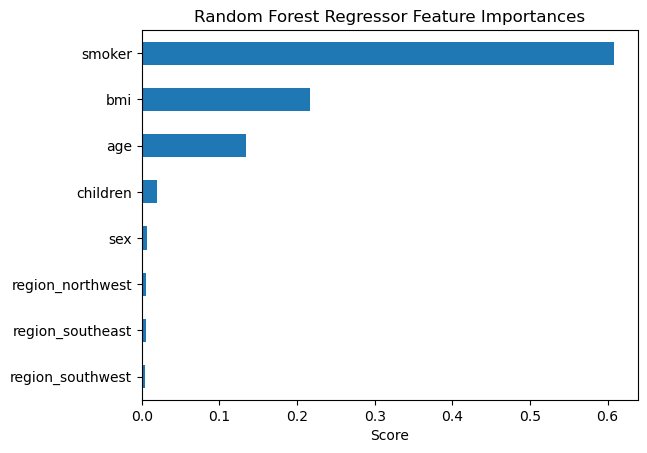

In [30]:
# Task 5

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

importances = pd.Series(rfr.feature_importances_, X_train.columns).sort_values()

importances.plot(kind='barh',
                 xlabel='Score',
                 title='Random Forest Regressor Feature Importances')



This plot matches what Lasso and SelectKBest found. They all agree that smoker is the number one influencer for charges, and bmi, age, and children and ranked as the next in different orders depending on the model.

In [33]:
# Task 6

pi = permutation_importance(rfr, X_test, y_test, n_repeats=10, random_state=0)
perm = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)

print("Permutation importance (test set):")
print(perm.round(4).to_string())

Permutation importance (test set):
smoker              1.3539
bmi                 0.2696
age                 0.1928
children            0.0275
region_southeast    0.0044
region_southwest    0.0035
region_northwest    0.0001
sex                -0.0022


The features look pretty similar to the previous findings. Evaluating on the test set gives more trustworthy results because the test data hasn't seen the results of any sort of importance ranking yet.

In [40]:
# Task 7

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=0))
])

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
gs.fit(X_train, y_train)

print(gs.best_params_)

{'model__max_depth': 5, 'model__n_estimators': 100}


The scaler is put inside of the Pipeline because the model may see significance in raw feature values that could be reduced if the features were scaled before making the model.

In [50]:
# Advanced Task 1

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "selection__k": [3, 5, 7]
}

pipe = Pipeline([
    ("selection", SelectKBest(score_func=f_regression)),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=0))
])

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
gs.fit(X_train, y_train)

best_pipe = gs.best_estimator_
selector = best_pipe.named_steps['selection']

selected_features = X_train.columns[selector.get_support()]

print("Best k:", selector.k)
print("Selected features:")
print(selected_features.tolist())

Best k: 7
Selected features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']


In [54]:
# Advanced Task 2

param_grid = {
    "model__n_estimators": [50, 100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 10, 20],
    "selection__k": [3, 4, 5, 6, 7]
}

pipe = Pipeline([
    ("selection", SelectKBest(score_func=f_regression)),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=0))
])

rs = RandomizedSearchCV(pipe, param_grid, n_iter=20, random_state=42)
rs.fit(X_train, y_train)

best_pipe = rs.best_estimator_
selector = best_pipe.named_steps['selection']

selected_features = X_train.columns[selector.get_support()]

print("Best k:", selector.k)
print("Selected features:")
print(selected_features.tolist())

Best k: 5
Selected features:
['age', 'bmi', 'children', 'smoker', 'region_southeast']


RandomizedSearchCV is for larger datasets and more parameters because it takes less time to run.